<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/k_brazos/softmax_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* Este notebook presenta un estudio detallado del rendimiento del algoritmo **Softmax** en un problema dek-armed bandit.

Se comparan diferentes configuraciones del parámetro de temperatura $\tau$ (tau) para analizar el compromiso entre exploración y explotación en el contexto de la distribución de recompensa **Normal**.

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/16

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

## Preparación del entorno

Importamos las librerías necesarias y copiamos nuestro repositorio del proyecto.

In [1]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git

Cloning into 'FernandezMartinezPolo-EML-RL'...
remote: Enumerating objects: 624, done.
remote: Counting objects: 100% (273/273), done.
remote: Compressing objects: 100% (196/196), done.
remote: Total 624 (delta 153), reused 166 (delta 77), pack-reused 351 (from 1)
Receiving objects: 100% (624/624), 33.52 MiB | 18.20 MiB/s, done.
Resolving deltas: 100% (350/350), done.


In [2]:
%cd FernandezMartinezPolo-EML-RL/k_brazos

/content/FernandezMartinezPolo-EML-RL/k_brazos


In [3]:
#Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('./src')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, Softmax
from arms import ArmNormal, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics


['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', './src']


## Diseño del experimento

En este notebook se analiza un problema de bandido multi-brazo de 10 brazos, donde cada brazo sigue una distribución Normal con media $\mu \in [1, 10]$ y desviación típica $\sigma = 1$. Se implementan cuatro variantes del algoritmo Softmax, utilizando distintos valores del parámetro de temperatura $\tau$.

A diferencia de estrategias como $\varepsilon$-Greedy, donde en cada paso se elige una acción aleatoria con probabilidad $\varepsilon$ y, en caso contrario, se selecciona la acción con mayor recompensa media estimada, el algoritmo Softmax asigna una probabilidad de selección a cada acción de forma proporcional a su valor estimado. En concreto, en cada iteración se selecciona la acción $a$ con probabilidad:

$$
P_t(a) = \frac{e^{Q_t(a) / \tau}}{\sum_{b=1}^k e^{Q_t(b) / \tau}}
$$

donde $Q_t(a)$ representa la estimación actual de la recompensa media de la acción $a$, y $\tau > 0$ es el parámetro de temperatura que controla el equilibrio entre exploración y explotación.

Podemos interpretar el efecto del parámetro $\tau$ sobre el comportamiento del agente de la siguiente manera: con valores altos de $\tau$, las diferencias entre los $Q_t(a)$ se diluyen y la distribución de probabilidad se aproxima a la uniforme, fomentando la exploración. Con valores bajos, las diferencias se amplifican y el algoritmo tiende a seleccionar casi siempre la acción con mayor valor estimado, comportándose de forma similar a una política greedy.

Es importante calibrar el valor de $\tau$ en relación con la escala de las recompensas del entorno, puesto que, como hemos comprobado empíricamente, valores desproporcionadamente pequeños o grandes respecto a las diferencias reales entre brazos producen comportamientos de sobreexplotación o sobreexploración extrema, desvirtuando los experimentos. Por ello, los cuatro valores seleccionados ($\tau = 0.1$, $\tau = 0.5$, $\tau = 1.0$ y $\tau = 5.0$) se han elegido de forma que sean acordes a la escala del entorno estudiado y cubran varios regímenes cualitativamente distintos, desde una política casi greedy ($\tau = 0.1$) hasta una exploración prácticamente uniforme ($\tau = 5.0$).

El interés de este experimento reside en que el algoritmo no utiliza información sobre el número de veces que se ha seleccionado cada brazo para guiar la exploración, sino que la probabilidad de selección depende únicamente de las estimaciones de valor $Q_t(a)$. Esto lo hace especialmente sensible a la calidad de dichas estimaciones en las primeras iteraciones, cuando aún son ruidosas. Estudiar su comportamiento con distintos valores de $\tau$ permite analizar cómo gestiona este algoritmo la incertidumbre inicial y en qué medida logra identificar y explotar el brazo óptimo a lo largo del tiempo. En definitiva, el experimento nos permite analizar cómo distintos niveles de exploración afectan al rendimiento del algoritmo a lo largo del aprendizaje.

### Configuración del Experimento
Cada política se evalúa a lo largo de 2000 iteraciones, y todo el experimento se repite 500 veces de forma independiente. En cada iteración se calcula la media de las recompensas obtenidas considerando esas 500 ejecuciones.

La razón por la que se usan 2000 iteraciones, es que se requiere un horizonte temporal suficientemente largo para observar el comportamiento asintótico de los algoritmos y obtener estimaciones estables del rechazo acumulado.

La comparación entre algoritmos se realiza utilizando varias métricas: recompensa media, proporción media de selecciones óptimas, rechazo acumulado medio y ganancia y número de selecciones promedio por brazo.

In [4]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar los rechazos promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    arm_stats = [{'mean_rewards': np.zeros(bandit.k), 'selections': np.zeros(bandit.k)} for _ in algorithms] #Para las arm stats

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        sum_current_run_expected_value = np.zeros(len(algorithms)) # Aquí se almacena el valor esperado acumulado para cada algoritmo de esta run. Necesario para calcular el rechazo

        for idx, algo in enumerate(algorithms):
            for step in range(steps):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.

                arm_stats[idx]['mean_rewards'][chosen_arm] += reward # Actualizar la ganancia del brazo seleccionado por el algoritmo.
                arm_stats[idx]['selections'][chosen_arm] += 1 # Actualizar el número de selecciones del brazo seleccionado por el algoritmo.

                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                # Modificar optimal_selections cuando el brazo elegido se corresponde con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                # Si el step actual es 0, el valor esperado acumulado se inicializa con el valor esperado del brazo
                # elegido actualmente. Si no, se suma el valor esperado del brazo actual al valor acumulado
                if step == 0:
                    sum_current_run_expected_value[idx] = bandit.get_expected_value(chosen_arm)
                else:
                    sum_current_run_expected_value[idx] = sum_current_run_expected_value[idx] + bandit.get_expected_value(chosen_arm)

                regrets[idx, step] += (step+1)*bandit.get_expected_value(optimal_arm) - sum_current_run_expected_value[idx]

    rewards /= runs
    regrets /= runs

    # Calcular el porcentaje de selecciones óptimas
    optimal_selections = optimal_selections*100/runs

    for stat in arm_stats:
      stat['mean_rewards'] /= runs
      stat['selections'] /= runs

    return rewards, regrets, optimal_selections, arm_stats


Definimos los parámetros del experimento seleccionados en la fase de diseño experimental:

In [5]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 2000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")


# Algoritmos a comparar (distintas temperaturas)
algorithms_normal = [
    Softmax(k=k, tau=0.1),
    Softmax(k=k, tau=0.5),
    Softmax(k=k, tau=1.0),
    Softmax(k=k, tau=5.0)
]

# Ejecutar
rewards_n, regrets_n, optimal_n, arm_stats_n = run_experiment(bandit, algorithms_normal, steps, runs)

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


Ahora exportamos los resultados para poder luego generar una gráfica conjuntamente con los otros algoritmos.

In [6]:
import os

# Create a directory to store the exported data
output_dir = 'exported_data'
os.makedirs(output_dir, exist_ok=True)

# Export data for Normal Distribution
np.savez(os.path.join(output_dir, 'softmax_normal_data.npz'),
         rewards=rewards_n,
         regrets=regrets_n,
         optimal_selections=optimal_n)
print(f"Normal experiment data saved to {os.path.join(output_dir, 'softmax_normal_data.npz')}")

Normal experiment data saved to exported_data/softmax_normal_data.npz


## Visualización de los resultados

#### Recompensa promedio

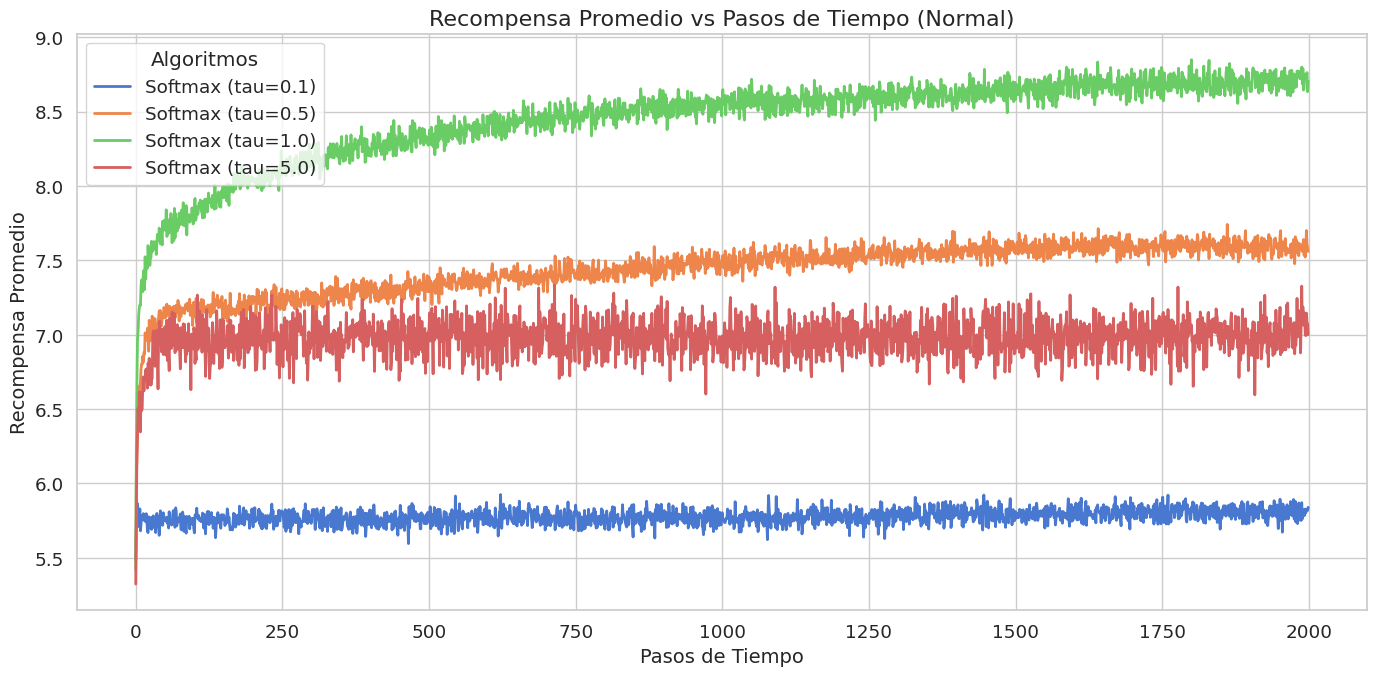

In [14]:
plot_average_rewards(steps, rewards_n, algorithms_normal, "Normal")


La gráfica compara el comportamiento de las distintas configuraciones del algoritmo **Softmax**. En el eje **x** aparecen los **pasos de tiempo**, mientras que en el eje **y** se representa la **recompensa promedio** obtenida por cada política a lo largo del proceso de aprendizaje.

##### **Interpretación de las líneas del gráfico**

Cada una de las cuatro líneas del gráfico se corresponde con una configuración distinta del parámetro de temperatura:

- **Azul (Softmax con $\tau = 0.1$):** Representa la estrategia más explotadora. Con una temperatura muy baja, las diferencias entre los valores estimados $Q_t(a)$ se amplifican exponencialmente, por lo que el algoritmo colapsa muy rápido hacia la acción con mayor estimación inicial, sin apenas explorar.
- **Naranja (Softmax con $\tau = 0.5$):** Representa una estrategia moderadamente explotadora. La temperatura es lo suficientemente baja como para dar preferencia a las mejores acciones, pero permite cierta exploración.
- **Verde (Softmax con $\tau = 1.0$):** Representa la temperatura de referencia natural para distribuciones Normales con $\sigma = 1$, ofreciendo un equilibrio entre exploración y explotación.
- **Roja (Softmax con $\tau = 5.0$):** Representa la estrategia más exploradora. Con una temperatura muy alta, las probabilidades de selección se aproximan a la distribución uniforme $1/k$, lo que implica una exploración casi aleatoria.

##### **Evolución de la recompensa promedio**

El gráfico muestra diferencias muy pronunciadas entre configuraciones, lo que contrasta con el comportamiento más uniforme observado por ejemplo en los algoritmos $ɛ$-greedy.

La línea verde ($\tau = 1.0$) es la que mejor rendimiento obtiene con diferencia, estabilizándose en torno a $8.7$ tras una fase de crecimiento rápida en los primeros 300 pasos. A continuación, la línea naranja ($\tau = 0.5$) alcanza valores cercanos a $7.6$, mostrando también crecimiento inicial pero convergiendo a un nivel notablemente inferior. La línea roja ($\tau = 5.0$) se estabiliza alrededor de $7.0$, con oscilaciones elevadas y persistentes durante todo el experimento, consecuencia directa de la exploración casi aleatoria. Por último, la línea azul ($\tau = 0.1$) muestra el peor resultado: se congela en torno a $5.8$ prácticamente desde el inicio, sin ninguna mejora a lo largo de las 2000 iteraciones.

El resultado más llamativo es que la estrategia más explotadora ($\tau = 0.1$) obtiene el peor rendimiento, mientras que la estrategia con temperatura media ($\tau = 1.0$) supera a todas. Esto indica que con $\tau = 0.1$ el algoritmo queda atrapado en un brazo subóptimo desde las primeras iteraciones, sin tener oportunidad de corregir sus estimaciones iniciales.

Cabe destacar que el brazo óptimo tiene una recompensa esperada de $9.56$, por lo que incluso la mejor configuración ($\tau = 1.0$) se sitúa casi un punto por debajo del óptimo teórico. El resto de configuraciones acumulan diferencias de entre $2$ y casi $4$ puntos, lo que pone en perspectiva la dificultad del Softmax con $\tau$ fijo para identificar
y explotar de forma consistente el brazo óptimo en este entorno.

#### Porcentaje de selección de la acción óptima

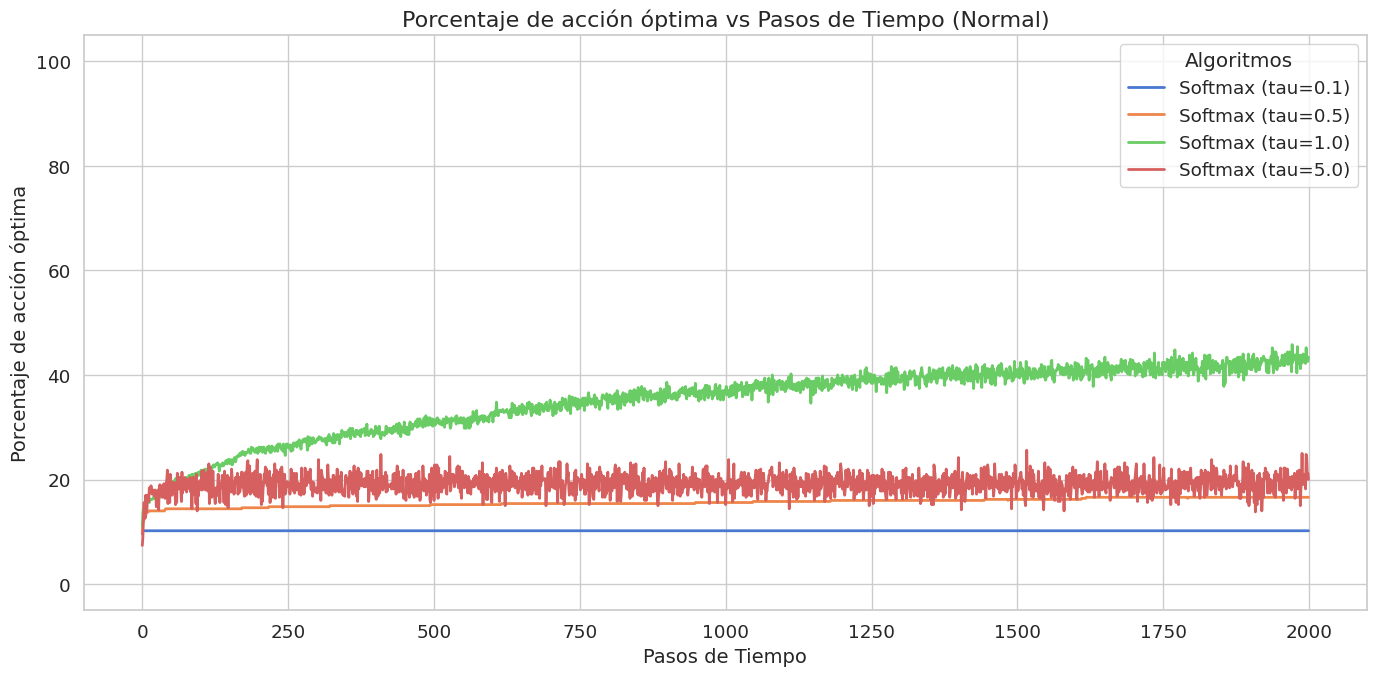

In [12]:
plot_optimal_selections(steps, optimal_n, algorithms_normal, "Normal")

En el eje **x** de la gráfica se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **porcentaje de veces que se selecciona la acción óptima**.

**Los colores del gráfico son totalmente equivalentes a los de la gráfica anterior.**

#####  **Evolución del porcentaje de acción óptima**

Los resultados de esta gráfica son llamativos y merecen una interpretación cuidadosa, ya que los porcentajes de selección óptima son notablemente bajos para todos los algoritmos en comparación con lo observado en las otras familias de algoritmos estudiadas en este proyecto.

La línea verde ($\tau = 1.0$) es la única que muestra una tendencia de mejora sostenida a lo largo del experimento, creciendo desde aproximadamente el $10\%$ hasta situarse en torno al $45\%$ al final de las 2000 iteraciones, aunque sin llegar a converger completamente. La línea roja ($\tau = 5.0$) se estabiliza alrededor del $20\%$ con oscilaciones constantes, lo que es coherente con una política casi aleatoria sobre 10 brazos. Las líneas naranja ($\tau = 0.5$) y azul ($\tau = 0.1$) se mantienen prácticamente planas durante todo el experimento, en torno al $15\%$ y al $10\%$ respectivamente.

Estos valores bajos de selección óptima, especialmente para $\tau = 0.1$ y $\tau = 0.5$, evidencian que el algoritmo se está quedando estancado en subóptimos. Este fenómenos se produce porque al explotar demasiado pronto, el algoritmo concentra sus selecciones en un brazo que no es el óptimo global, y la temperatura fija impide que corrija este error a lo largo del tiempo. El valor del $10\%$ de la línea azul es especialmente interesante, ya que con 10 brazos, una política aleatoria obtendría exactamente ese porcentaje en esperanza, lo que indica que Softmax con $\tau = 0.1$ no está aprendiendo nada sobre el brazo óptimo real.

#### Rechazo acumulado

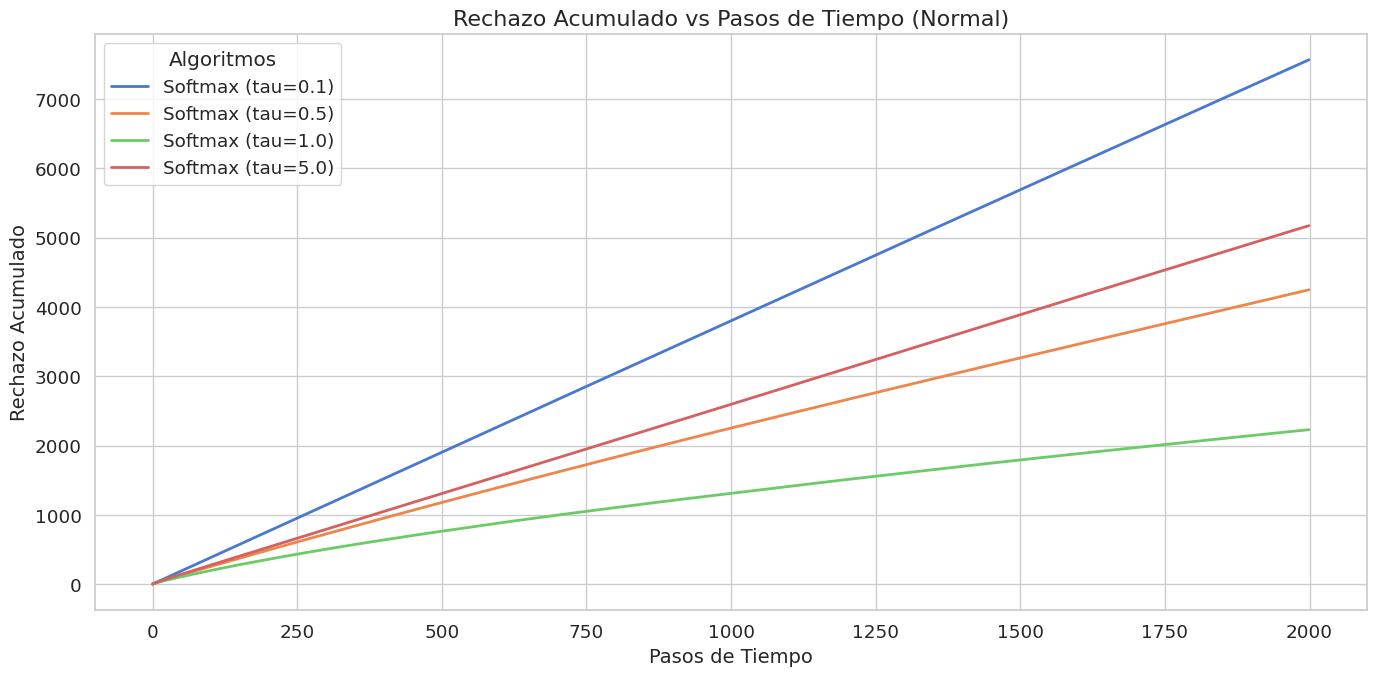

In [13]:
plot_regret(steps, regrets_n, algorithms_normal, "Normal")

En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **rechazo acumulado**.

**Los colores del gráfico son totalmente equivalentes a los de la gráfica anterior.**


##### **Evolución global del rechazo acumulado**

A diferencia de lo observado en los algoritmos UCB y $ɛ$-greedy, donde al menos las mejores configuraciones mostraban una tendencia a disminuir su crecimiento del rechazo acumulado, aquí todas las curvas presentan un crecimiento prácticamente lineal a partir de las primeras iteraciones y a lo largo de todo el experimento. Esto parece confirmar que ninguna configuración de Softmax con $\tau$ fijo consigue converger al brazo óptimo de forma estable, acumulando un rechazo proporcional al número de pasos.

- **Azul ($\tau = 0.1$):** Peor resultado (~7600), con la pendiente más pronunciada desde el inicio. A pesar de ser la más explotadora, explota un brazo subóptimo.
- **Roja ($\tau = 5.0$):** Segundo peor resultado (~5200). La exploración casi aleatoria impide concentrar selecciones en el brazo óptimo.
- **Naranja ($\tau = 0.5$):** Resultado intermedio (~4300). Mejor que los extremos, aunque sigue sin identificar el óptimo de forma consistente.
- **Verde ($\tau = 1.0$):** Mejor resultado con diferencia (~2300). Se aprecia una ligera curva que sugiere un cierto aprendizaje, aunque es poco significativa.


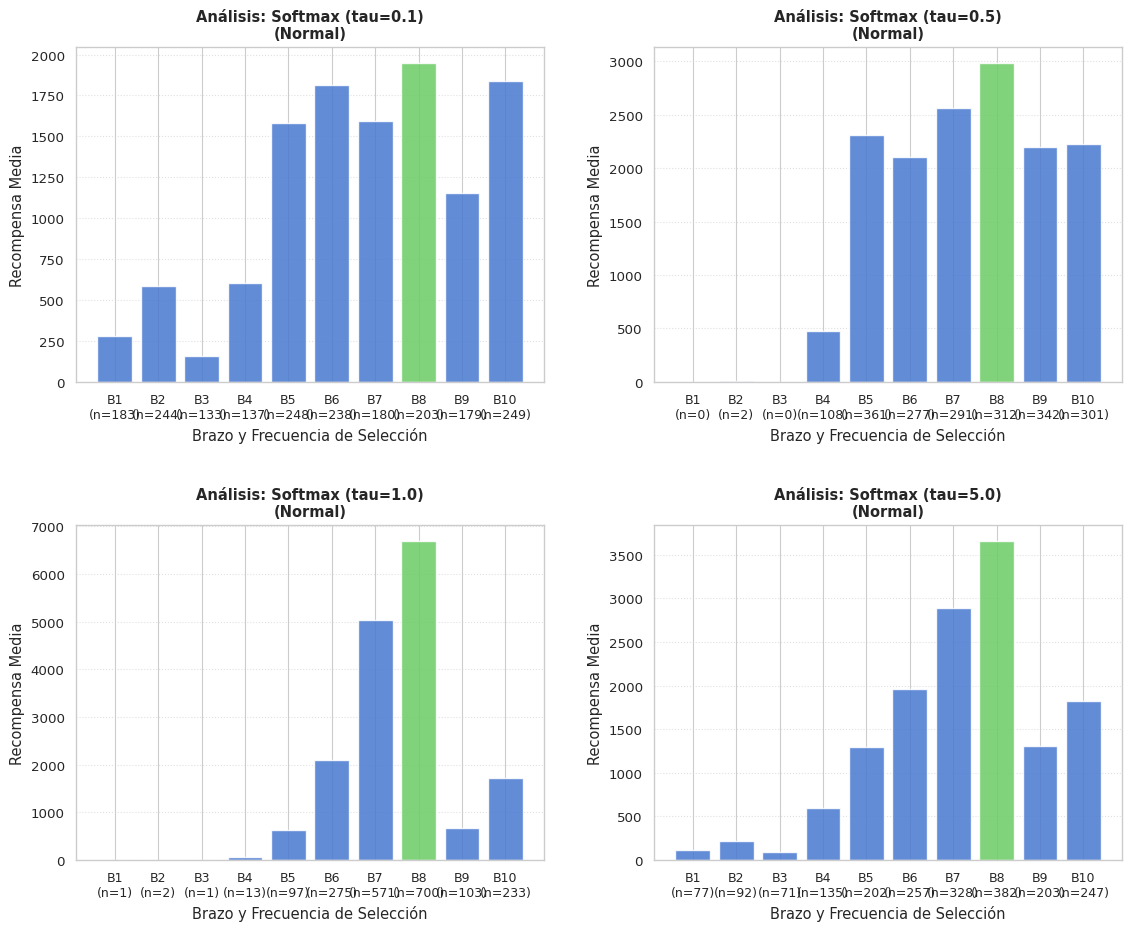

In [11]:
plot_arm_statistics(arm_stats_n, algorithms_normal, k, optimal_arm, "Normal")

La imagen muestra cuatro gráficos de barras, en los que el eje x se representa cada uno de los brazos del bandido, indicando entre paréntesis el número medio de selecciones por brazo a lo largo de las 500 ejecuciones, y  en el eje y se muestra la ganancia media obtenida de cada brazo. La barra del brazo óptimo (B8, con $\mu = 9.56$) se muestra en verde para diferenciarla del resto.

Las cuatro gráficas reflejan y refuerzan de forma muy clara todo lo observado en las métricas anteriores. Para $\tau = 1.0$, las selecciones se concentran mayoritariamente en el brazo óptimo B8 ($n = 700$) y en el segundo mejor brazo B7 ($n = 571$), con una presencia residual del resto, lo que es coherente con el mejor rendimiento global que esta configuración mostró en todas las métricas. Para $\tau = 0.5$, la distribución es más repartida entre los brazos de mayor recompensa (B6 a B10), con ninguna concentración clara en el óptimo ($n = 312$), lo que explica su recompensa promedio moderada y su bajo porcentaje de selección óptima. Para $\tau = 5.0$, las selecciones se distribuyen de forma más uniforme entre todos los brazos, aunque con cierta preferencia por los de mayor recompensa, reflejando la exploración casi aleatoria característica de temperaturas altas. Finalmente, $\tau = 0.1$ presenta la distribución más dispersa de todas, con selecciones repartidas prácticamente por igual entre todos los brazos incluyendo los peores, lo que confirma el comportamiento observado y analizado previamente. Podemos extraer de estos resultados que el algoritmo ha explotado prematuramente brazos que no son el óptimo y ha mantenido esa política durante todo el experimento.

Es importante tener en cuenta que estas gráficas agregan el comportamiento a lo largo de todas las ejecuciones y todos los pasos de tiempo. Por ello, una distribución de selecciones repartida entre varios brazos no implica que el algoritmo haya explorado de forma inteligente, sino que en distintas ejecuciones ha quedado atrapado en distintos subóptimos. Este matiz es especialmente relevante para $\tau = 0.1$, donde la aparente diversidad de selecciones no refleja exploración, sino inestabilidad entre ejecuciones, cada una atascada en un brazo diferente.

Estos resultados son coherentes con la intuición teórica sobre el comportamiento del algoritmo que habíamos propuesto previa al experimento.

## Conclusiones

El resultado más destacable del experimento es que ninguna configuración de Softmax con $\tau$ fijo consigue converger al brazo óptimo de forma estable a lo largo de las 2000 iteraciones. Esto se manifiesta no solo en el crecimiento estrictamente lineal del rechazo acumulado para todas las configuraciones, en claro contraste con el comportamiento sublineal que exhiben los otros algoritmos estudiados en el proyecto, sino también en los valores de recompensa promedio obtenidos, que se sitúan muy por debajo de la recompensa esperada del brazo óptimo ($9.56$) y son notablemente inferiores a los alcanzados por los otros algoritmos en condiciones equivalentes.

Aunque esperábamos obtener mejores resultados, especialmente para las configuraciones óptimas de temperatura moderada, el experimento nos ha permitido identificar y comprender las limitaciones intrínsecas del algoritmo.

A partir de estos resultados, planteamos que la causa principal que las justifica es la naturaleza estática del parámetro $\tau$: una temperatura fija obliga al algoritmo a mantener indefinidamente un nivel constante de exploración o explotación, impidiéndole adaptarse a medida que sus estimaciones mejoran. Los casos extremos ilustran bien este problema: $\tau = 0.1$ colapsa desde el inicio en un brazo subóptimo sin posibilidad de corregir esa decisión, mientras que $\tau = 5.0$ nunca abandona una exploración casi aleatoria.

La configuración $\tau = 1.0$ es la que mejor se comporta en este entorno concreto, logrando la mayor recompensa promedio y el menor rechazo acumulado, aunque sin llegar a superar el $45\%$ de selecciones óptimas al final del experimento. Este resultado pone de manifiesto que el rendimiento del Softmax es altamente sensible a la elección de $\tau$ en relación con la escala de las recompensas del entorno: en este caso, $\tau = \sigma = 1.0$ resulta ser la referencia natural que mejor equilibra exploración y explotación para brazos Normales con $\sigma = 1$.

Pese a los resultados inferiores a los esperados, consideramos el experimento satisfactorio, ya que nos ha permitido evaluar de forma clara el efecto del parámetro $\tau$ sobre el comportamiento del algoritmo, verificar empíricamente cómo distintos niveles de temperatura producen regímenes cualitativamente distintos y constatar los límites del Softmax con temperatura fija en entornos de distribución Normal, planteando una hipótesis sobre las causas de dichas limitaciones.